# Predictive Maintenance: NASA C-MAPSS (FD001)
Goal: predict **Remaining Useful Life (RUL)** of turbofan engines.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

1. Load data

In [2]:
DATA_DIR = "data"

index_cols = ["unit_id", "cycle"]
setting_cols = [f"op_{i}" for i in range(1, 4)]
sensor_cols = [f"s_{i}" for i in range(1, 22)]
col_names = index_cols + setting_cols + sensor_cols

# raw files: space-separated, no header
train = pd.read_csv(f"{DATA_DIR}/train_FD001.txt", sep=r"\s+", header=None, names=col_names)
test  = pd.read_csv(f"{DATA_DIR}/test_FD001.txt",  sep=r"\s+", header=None, names=col_names)
rul_test = pd.read_csv(f"{DATA_DIR}/RUL_FD001.txt", sep=r"\s+", header=None, names=["true_rul"])

print("train:", train.shape, "| test:", test.shape, "| rul_test:", rul_test.shape)
train.head()

train: (20631, 26) | test: (13096, 26) | rul_test: (100, 1)


,unit_id,cycle,op_1,op_2,op_3,s_1,s_2,s_3,s_4,s_5,...,s_12,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


2. EDA

In [3]:
print("Engines in train:", train["unit_id"].nunique())
print("Engines in test :", test["unit_id"].nunique())
print("Missing values  :", train.isna().sum().sum())
train.describe().T

Engines in train: 100
Engines in test : 100
Missing values  : 0


,count,mean,std,min,25%,50%,75%,max
unit_id,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
op_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
op_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
op_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
s_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
s_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
s_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
s_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
s_5,20631.0,14.620000,5.329200e-15,14.6200,14.6200,14.6200,14.6200,14.6200


count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64


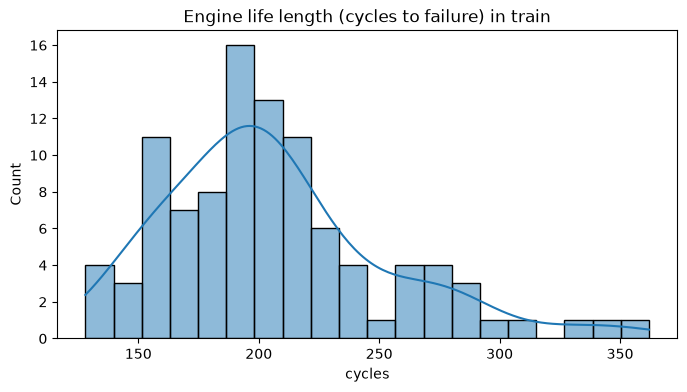

In [4]:
life = train.groupby("unit_id")["cycle"].max()
print(life.describe())

plt.figure(figsize=(8, 4))
sns.histplot(life, bins=20, kde=True)
plt.title("Engine life length (cycles to failure) in train")
plt.xlabel("cycles")
plt.show()

Useless sensors:
Sensors with (near) zero variance carry no information. Drop them.

In [5]:
cols_to_check = sensor_cols + setting_cols

flat_cols = []
for col in cols_to_check:
    if train[col].std() < 0.00001:
        flat_cols.append(col)

print("Flat dropped columns:", flat_cols)

Flat dropped columns: ['s_1', 's_5', 's_10', 's_16', 's_18', 's_19', 'op_3']


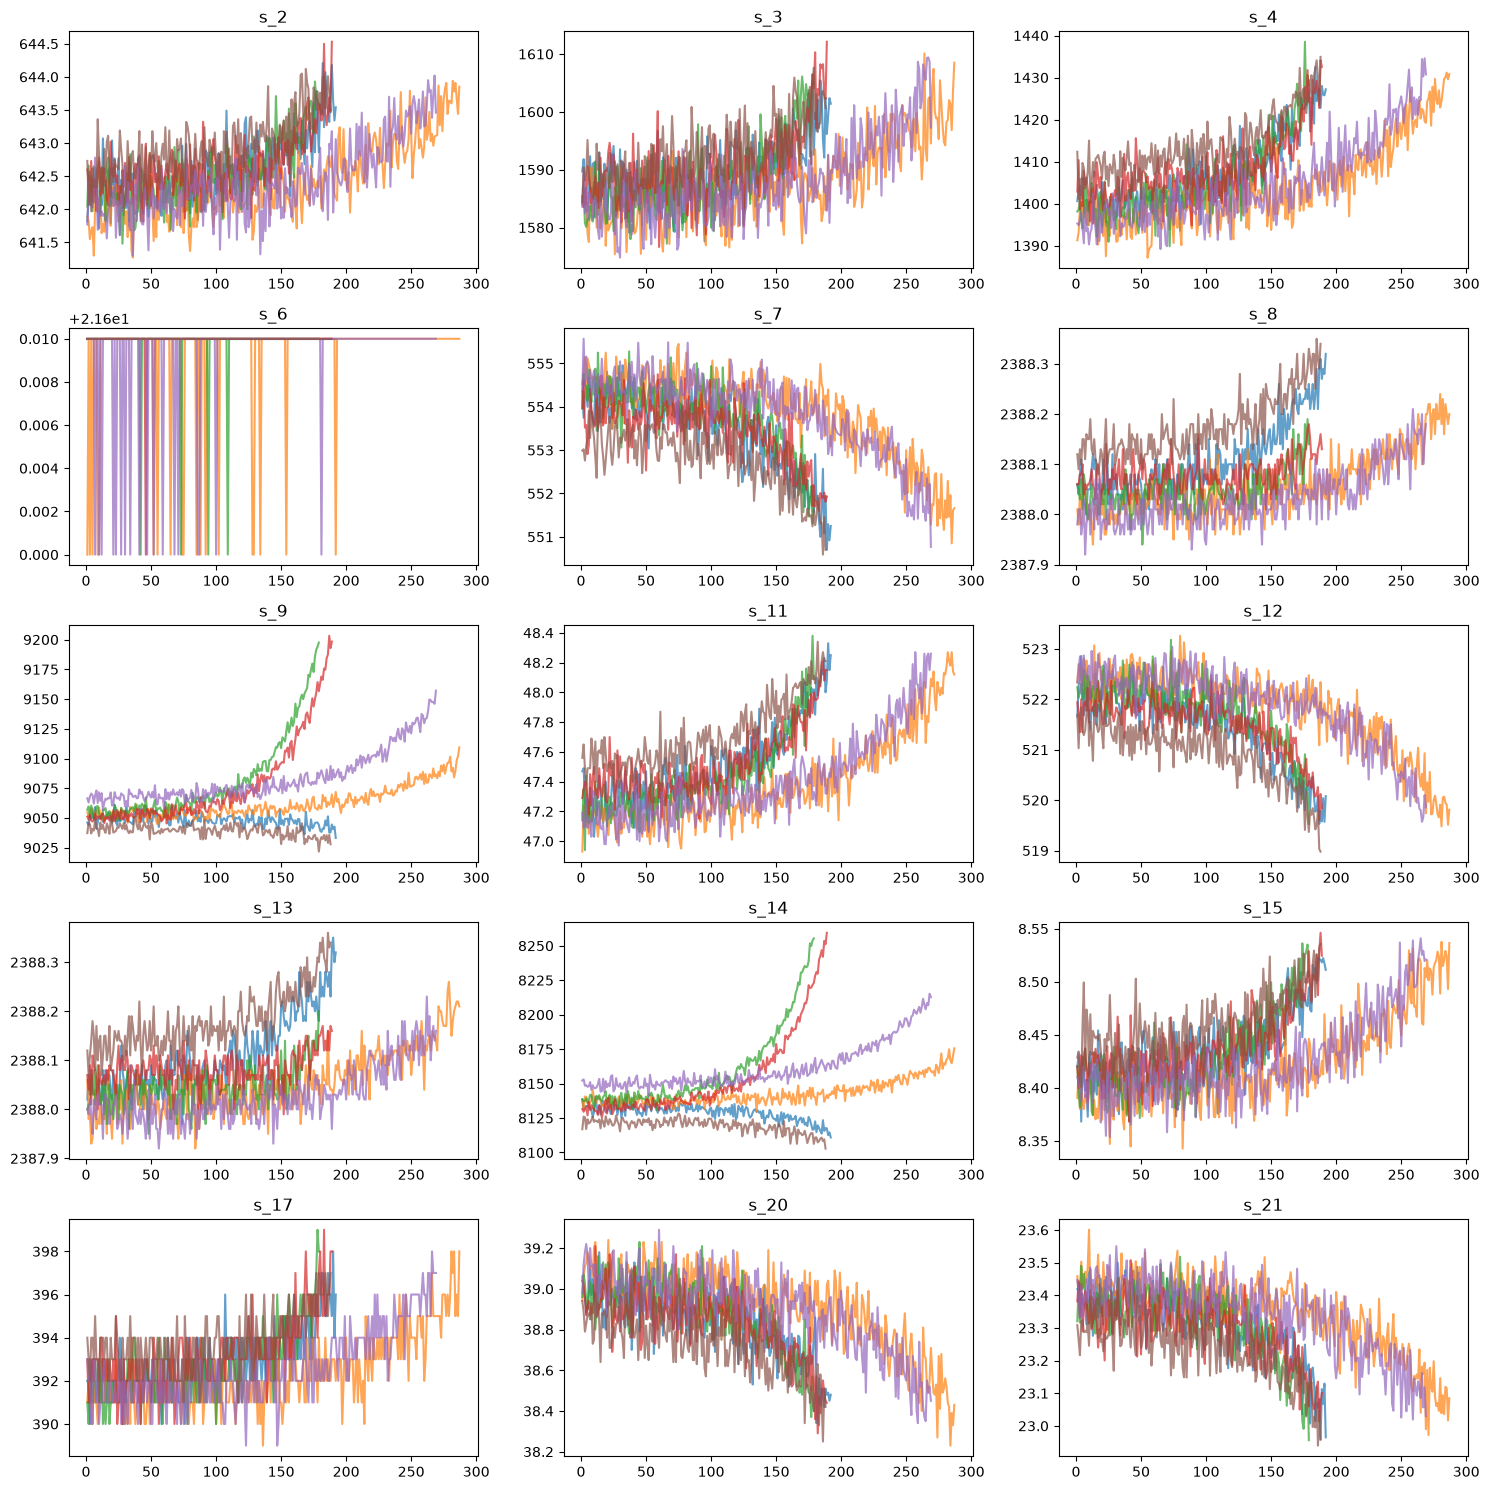

In [6]:
useful_sensors = [c for c in sensor_cols if c not in flat_cols]
sample_units = train["unit_id"].unique()[:6]

n = len(useful_sensors)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3 * nrows))
axes = axes.ravel()

for ax, s in zip(axes, useful_sensors):
    for u in sample_units:
        d = train[train["unit_id"] == u]
        ax.plot(d["cycle"], d[s], alpha=0.7)
    ax.set_title(s)
for ax in axes[n:]:
    ax.axis("off")
plt.tight_layout()
plt.show()

Noise: raw vs. smoothed

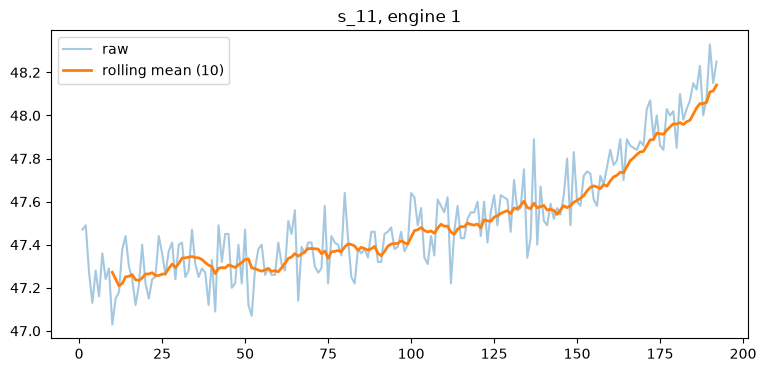

In [ ]:
unit = train[train["unit_id"] == 1]
s = "s_11" 

plt.figure(figsize=(9, 4))
plt.plot(unit["cycle"], unit[s], alpha=0.4, label="raw")
plt.plot(unit["cycle"], unit[s].rolling(10).mean(), linewidth=2, label="rolling mean (10)")
plt.title(f"{s}, engine 1")
plt.legend()
plt.show()

Correlations:
Highly correlated sensors are redundant. Sensors correlated with cycle are tracking degradation.

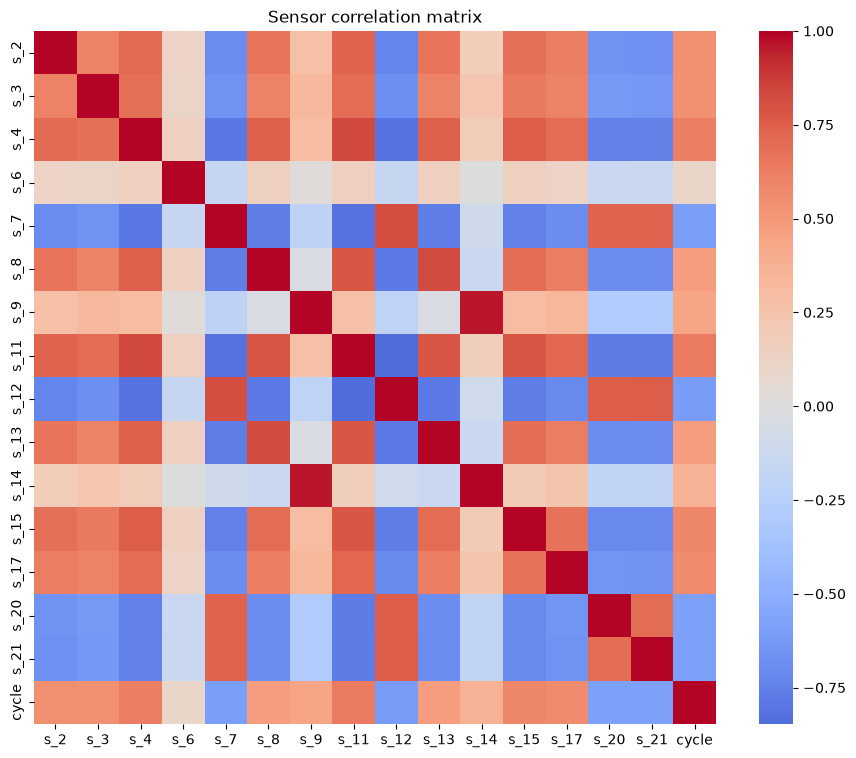

Sensors most correlated with cycle:
s_11    0.634
s_4     0.625
s_12    0.611
s_7     0.596
s_15    0.589
s_21    0.586
s_20    0.584
s_17    0.567
Name: cycle, dtype: float64


In [8]:
corr = train[useful_sensors + ["cycle"]].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Sensor correlation matrix")
plt.show()

print("Sensors most correlated with cycle:")
print(corr["cycle"].drop("cycle").abs().sort_values(ascending=False).head(8).round(3))